In [1]:
import pandas as pd
import networkx as nx
import numpy as np
import scipy as scp
import matplotlib.pyplot as plt
from copy import deepcopy

In [ ]:
from utils.pandas_utils import saver

In [3]:
main_df = pd.read_csv(f"small_data/main_df.csv")

In [4]:
main_df

,Exp_ID,Image_Metadata_Site,track_id,Image_Metadata_T,Nuclear_size,ERKKTR_ratio,FoxO3A_ratio,objNuclei_Location_Center_X,objNuclei_Location_Center_Y
0,1,1,1,0,303.000,0.704407,1.33383,932.211,875.248
1,1,1,1,1,333.000,0.848242,1.33791,932.150,874.174
2,1,1,1,2,314.000,1.059170,1.37627,932.376,873.787
3,1,1,1,3,322.000,1.188000,1.35754,932.168,873.453
4,1,1,1,4,313.999,1.205540,1.36695,931.146,872.885
...,...,...,...,...,...,...,...,...,...
356627,1,1,2857,253,165.000,0.597341,1.32403,1019.050,771.624
356628,1,1,2857,254,192.000,0.587024,1.28853,1019.060,773.099
356629,1,1,2857,255,200.000,0.587822,1.28325,1019.100,773.540
356630,1,1,2857,256,192.000,0.579069,1.29542,1018.930,772.469


In [5]:
sorted_main_df = main_df.set_index(['Image_Metadata_T', 'track_id']).sort_index()
sorted_main_df

Exp_ID  Image_Metadata_Site  Nuclear_size  \
Image_Metadata_T track_id                                              
0                1              1                    1       303.000   
                 2              1                    1       268.001   
                 3              1                    1       370.000   
                 4              1                    1       341.000   
                 5              1                    1       308.000   
...                           ...                  ...           ...   
257              2849           1                    1       165.000   
                 2850           1                    1       138.000   
                 2855           1                    1       148.000   
                 2856           1                    1       148.000   
                 2857           1                    1       175.000   

                           ERKKTR_ratio  FoxO3A_ratio  \
Image_Metadata_T track_id                               
0                1             0.704407       1.33383   
                 2             1.227760       1.20592   
                 3             0.779226       1.27561   
                 4             0.870780       1.34460   
                 5             0.807262       1.47321   
...                                 ...           ...   
257              2849          0.607956       1.31242   
                 2850          0.775133       1.15722   
                 2855          1.114600       1.25315   
                 2856          0.861735       1.16059   
                 2857          0.589269       1.31594   

                           objNuclei_Location_Center_X  \
Image_Metadata_T track_id                                
0                1                             932.211   
                 2                             162.328   
                 3                             647.816   
                 4                             642.988   
                 5                             990.718   
...                                                ...   
257              2849                          839.988   
                 2850                         1019.510   
                 2855                          411.797   
                 2856                         1018.580   
                 2857                         1018.850   

                           objNuclei_Location_Center_Y  
Image_Metadata_T track_id                               
0                1                            875.2480  
                 2                            365.4140  
                 3                            846.5760  
                 4                            827.8650  
                 5                             59.4675  
...                                                ...  
257              2849                         877.9760  
                 2850                          50.1159  
                 2855                         205.4320  
                 2856                         809.4530  
                 2857                         771.6110  

[356632 rows x 7 columns]

In [6]:
def extract_points_from_df(df: pd.DataFrame) -> np.ndarray:
    return df[["objNuclei_Location_Center_X", "objNuclei_Location_Center_Y"]].to_numpy()

In [7]:
def extract_bbox_from_df(df: pd.DataFrame) -> tuple[float, float, float, float]:
    return (
        df['objNuclei_Location_Center_X'].min(), 
        df['objNuclei_Location_Center_X'].max(),
        df['objNuclei_Location_Center_Y'].min(), 
        df['objNuclei_Location_Center_Y'].max()
    )

In [8]:
def extract_max_area_from_df(df: pd.DataFrame) -> float:
    return df['Nuclear_size'].max()

In [9]:
points = extract_points_from_df(sorted_main_df.loc[0])
points

array([[932.211, 875.248],
       [162.328, 365.414],
       [647.816, 846.576],
       ...,
       [641.391, 484.603],
       [806.226, 828.541],
       [704.24 , 894.894]], shape=(1409, 2))

In [10]:
vor_diag = scp.spatial.Voronoi(points)

vor_diag.points

array([[932.211, 875.248],
       [162.328, 365.414],
       [647.816, 846.576],
       ...,
       [641.391, 484.603],
       [806.226, 828.541],
       [704.24 , 894.894]], shape=(1409, 2))

In [11]:
def draw_voronoi(voronoi_diag: scp.spatial.Voronoi) -> None:
    fig = scp.spatial.voronoi_plot_2d(voronoi_diag, line_width = 0.5, point_size = 5, show_vertices = False)
    plt.show()

In [12]:
def convert_index_point_to_pos_dict(voronoi_diag: scp.spatial.Voronoi) -> dict[int, np.ndarray]:
        return {i: point for i, point in enumerate(voronoi_diag.points)}

In [13]:
def draw_voronoi_graphed(voronoi_diag: scp.spatial.Voronoi) -> None:
    graph: nx.Graph = nx.Graph()

    graph.add_edges_from(voronoi_diag.ridge_points)
 

    nx.draw(graph, node_size=7, width = 0.5, with_labels=False, pos=convert_index_point_to_pos_dict(voronoi_diag), node_color = 'red')

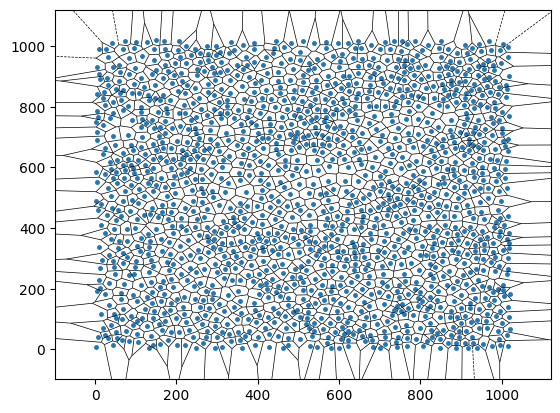

In [14]:
draw_voronoi(vor_diag)

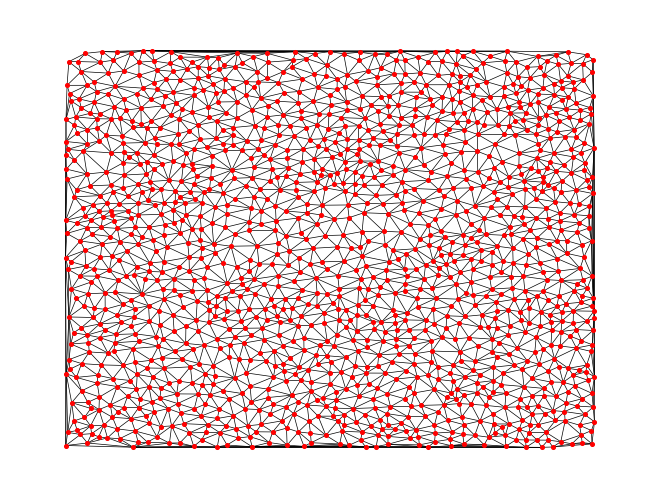

In [15]:
draw_voronoi_graphed(vor_diag)

In [16]:
def calculate_max_cell_xy(max_area: float) -> tuple[float, float]:
    return np.sqrt(max_area / np.pi) * 2, np.sqrt(max_area / np.pi) * 2

In [17]:
def estimate_correct_bbox(max_cell_area: float, raw_bbox: tuple[float, float, float, float]) -> tuple[float, float, float, float]:
    max_cell_xy = calculate_max_cell_xy(max_cell_area)

    bbox_x_ext, bbox_y_ext = max_cell_xy[0]/2, max_cell_xy[1]/2

    return (
        raw_bbox[0] - bbox_x_ext, 
        raw_bbox[1] + bbox_x_ext, 
        raw_bbox[2] - bbox_y_ext, 
        raw_bbox[3] + bbox_y_ext
    )

In [18]:
vor_diag.point_region

array([1294, 1397, 1077, ...,  959,  547, 1180], shape=(1409,))

In [19]:
vor_diag.regions

[[19, 16, 8, 17],
 [36, 27, 25, 34],
 [42, 9, 11, 10, 1, 0, 5, 4, 41],
 [60, 14, 2, -1, 6, 59],
 [61, 14, 60],
 [64, 61, 14, 2, 62],
 [63, 15, -1, 2, 62],
 [67, 65, 64, 62, 63, 66],
 [103, 101, 99, 100, 102],
 [103, 30, 31, 32, 33, 101],
 [103, 30, 25, 34, 35, 102],
 [111, 107, 106, 109, 108, 110],
 [110, 28, 29, 98, 108],
 [111, 99, 101, 33, 28, 110],
 [122, 119, 118, 117, 120, 121],
 [132, 130, 129, 128, 127, 131],
 [146, 144, 143, 145],
 [144, 48, 47, 46, 143],
 [152, 150, 149, 151],
 [161, 43, 10, 11, 158],
 [159, 154, 9, 11, 158],
 [160, 156, 155, 154, 159],
 [162, 50, 157, 156, 160],
 [173, 163, 165, 169, 171, 172],
 [194, 192, 191, 51, 189, 187, 193],
 [232, 205, 202, 224, 223, 231],
 [236, 15, 63, 66, 235],
 [237, 68, 7, -1, 15, 236],
 [264, 249, 250, 246, 247, 263],
 [275, 163, 173, 175, 273],
 [275, 163, 165, 164, 274],
 [317, 3, 76, 314],
 [318, -1, 141, 142, 316],
 [318, -1, 3, 317],
 [324, 322, 321, 319, 320, 323],
 [323, 315, 140, 20, 320],
 [322, 78, 17, 19, 18, 321],
 [

In [20]:
def cut_vertexes_of_voronoi(
        voronoi_diag: scp.spatial.Voronoi, 
        estimated_bbox: tuple[float, float, float, float],
    ) -> scp.spatial.Voronoi:
    """
    Cuts vertexes of voronoi diagram to given bbox

    :param estimated_bbox: (xmin, xmax, ymin, ymax)
    """

    new_vor_diag: scp.spatial.Voronoi = deepcopy(voronoi_diag)


    new_regions: list[list[float]] = []

    for region_verts in new_vor_diag.regions:
        new_regions.append([vert for vert in region_verts if vert != -1])

    new_vor_diag.regions = new_regions

    new_vertices: list[list[float]] = []

    for x_val, y_val in voronoi_diag.vertices:

        if x_val < estimated_bbox[0]:
            x_val = estimated_bbox[0]
        
        if x_val > estimated_bbox[1]:
            x_val = estimated_bbox[1]

        if y_val < estimated_bbox[2]:
            y_val = estimated_bbox[2]

        if y_val > estimated_bbox[3]:
            y_val = estimated_bbox[3]

        
        new_vertices.append([x_val, y_val])
        

    
    new_vor_diag.vertices = np.array(new_vertices)

    return new_vor_diag

In [21]:
estimated_bbox = estimate_correct_bbox(
    extract_max_area_from_df(sorted_main_df.loc[0]),
    extract_bbox_from_df(sorted_main_df.loc[0])
)

estimated_bbox

(np.float64(-16.33259964331453),
 np.float64(1038.5725996433146),
 np.float64(-16.41830964331453),
 np.float64(1038.1725996433145))

In [22]:
def cut_voronoi_to_bbox(
        voronoi_diag: scp.spatial.Voronoi,
        bbox: tuple[float, float, float, float],
) -> scp.spatial.Voronoi:
    xmin, xmax, ymin, ymax = bbox
    new_vor = deepcopy(voronoi_diag)

    new_vertices = list(new_vor.vertices)

    def add_vertex(point: tuple[float, float]) -> int:
        for i, v in enumerate(new_vertices):
            if abs(v[0] - point[0]) < 1e-10 and abs(v[1] - point[1]) < 1e-10:
                return i
        new_vertices.append(list(point))
        return len(new_vertices) - 1

    def intersect_segment_bbox(a, b):
        dx, dy = b[0] - a[0], b[1] - a[1]
        t_vals = []
        for edge_t, condition in [
            (((xmin - a[0]) / dx) if abs(dx) > 1e-10 else None, lambda p: ymin <= p[1] <= ymax),
            (((xmax - a[0]) / dx) if abs(dx) > 1e-10 else None, lambda p: ymin <= p[1] <= ymax),
            (((ymin - a[1]) / dy) if abs(dy) > 1e-10 else None, lambda p: xmin <= p[0] <= xmax),
            (((ymax - a[1]) / dy) if abs(dy) > 1e-10 else None, lambda p: xmin <= p[0] <= xmax),
        ]:
            if edge_t is not None and 0 < edge_t:
                pt = (a[0] + edge_t * dx, a[1] + edge_t * dy)
                if condition(pt):
                    t_vals.append((edge_t, pt))
        if not t_vals:
            return None
        t_vals.sort(key=lambda x: x[0])
        return t_vals[0][1]

    def is_inside_bbox(p):
        return xmin <= p[0] <= xmax and ymin <= p[1] <= ymax

    def clamp_to_bbox(p):
        return (float(np.clip(p[0], xmin, xmax)), float(np.clip(p[1], ymin, ymax)))

    # Mapa: oryginalny ridge_idx -> [v1, v2] lub None jeśli poza bbox
    ridge_map: dict[int, list[int] | None] = {}

    for ridge_idx, (v1_idx, v2_idx) in enumerate(new_vor.ridge_vertices):

        if v1_idx != -1 and v2_idx != -1:
            v1 = new_vor.vertices[v1_idx]
            v2 = new_vor.vertices[v2_idx]
            v1_in = is_inside_bbox(v1)
            v2_in = is_inside_bbox(v2)

            if v1_in and v2_in:
                ridge_map[ridge_idx] = [v1_idx, v2_idx]

            elif v1_in and not v2_in:
                pt = intersect_segment_bbox(v1, v2)
                ridge_map[ridge_idx] = [v1_idx, add_vertex(pt)] if pt else None

            elif not v1_in and v2_in:
                pt = intersect_segment_bbox(v2, v1)
                ridge_map[ridge_idx] = [add_vertex(pt), v2_idx] if pt else None

            else:
                ridge_map[ridge_idx] = None  # oba poza bbox

        else:
            finite_idx = v2_idx if v1_idx == -1 else v1_idx
            if finite_idx == -1:
                ridge_map[ridge_idx] = None
                continue

            finite_v = new_vor.vertices[finite_idx]
            if not is_inside_bbox(finite_v):
                ridge_map[ridge_idx] = None
                continue

            clamped = clamp_to_bbox(finite_v)
            ridge_map[ridge_idx] = [finite_idx, add_vertex(clamped)]

    # --- Przebudowa ridge_points i ridge_vertices (tylko ważne krawędzie) ---
    valid_ridge_indices = [i for i, v in ridge_map.items() if v is not None]

    new_vor.ridge_vertices = [ridge_map[i] for i in valid_ridge_indices]
    new_vor.ridge_points = np.array([new_vor.ridge_points[i] for i in valid_ridge_indices])
    new_vor.vertices = np.array(new_vertices)

    # --- Przebudowa regions ---
    n_points = len(new_vor.points)
    region_vertex_sets = [set() for _ in range(n_points)]

    # Teraz ridge_points i ridge_vertices są spójne — iterujemy razem
    for (rp1, rp2), (v1, v2) in zip(new_vor.ridge_points, new_vor.ridge_vertices):
        region_vertex_sets[rp1].update([v1, v2])
        region_vertex_sets[rp2].update([v1, v2])

    new_regions = list(new_vor.regions)
    new_regions_map = {}

    for point_idx in range(n_points):
        verts = list(region_vertex_sets[point_idx])
        if not verts:
            continue
        pts = np.array([new_vor.vertices[v] for v in verts])
        centroid = pts.mean(axis=0)
        angles = np.arctan2(pts[:, 1] - centroid[1], pts[:, 0] - centroid[0])
        order = np.argsort(angles)
        sorted_verts = [verts[i] for i in order]
        new_regions_map[point_idx] = len(new_regions)
        new_regions.append(sorted_verts)

    new_point_region = list(new_vor.point_region)
    for point_idx, region_idx in new_regions_map.items():
        new_point_region[point_idx] = region_idx

    new_vor.regions = new_regions
    new_vor.point_region = np.array(new_point_region)

    return new_vor

In [23]:
cutted_vor_diag = cut_voronoi_to_bbox(vor_diag, estimated_bbox)

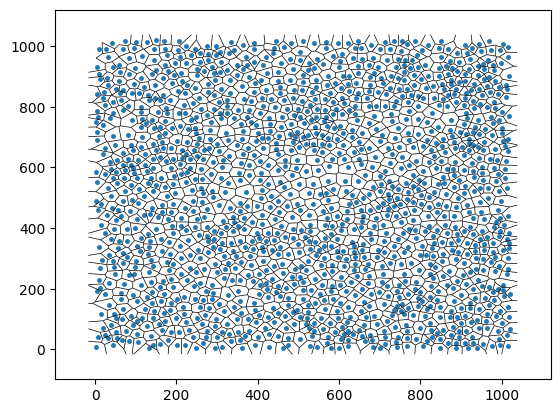

In [24]:
draw_voronoi(cutted_vor_diag)

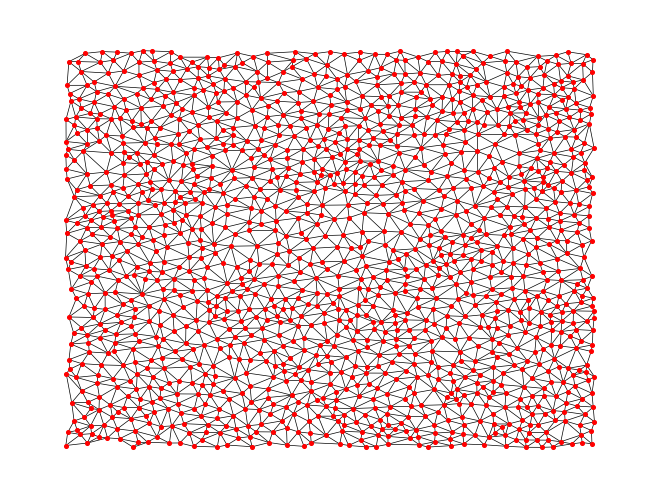

In [25]:
draw_voronoi_graphed(cutted_vor_diag)

In [26]:
vor_graph: nx.Graph = nx.Graph()

vor_graph.add_edges_from(cutted_vor_diag.ridge_points)

In [27]:
nx.set_node_attributes(vor_graph, convert_index_point_to_pos_dict(vor_diag), "pos")

In [28]:
def calculate_distance(pos1: np.ndarray, pos2: np.ndarray) -> np.float32:
    return np.linalg.norm(pos1 - pos2)

In [29]:
def add_distance_to_graph_edges(graph: nx.Graph):
    nodes_attrs = nx.get_node_attributes(graph, "pos")
    edges_attrs_dict: dict[tuple[int, int], np.float32] = {}

    for node in graph.nodes:
        for node_neigh in graph.neighbors(node):
            if (node, node_neigh) not in edges_attrs_dict.keys():
                edges_attrs_dict[(node, node_neigh)] = nodes_attrs[node_neigh]

    nx.set_edge_attributes(graph, edges_attrs_dict, name = 'dist')

In [30]:
add_distance_to_graph_edges(vor_graph)

In [31]:
def draw_pure_graph(graph: nx.Graph) -> None:
    nx.draw(graph, node_size=7, width = 0.5, with_labels=False, pos=nx.get_node_attributes(graph, "pos"), node_color = 'red')

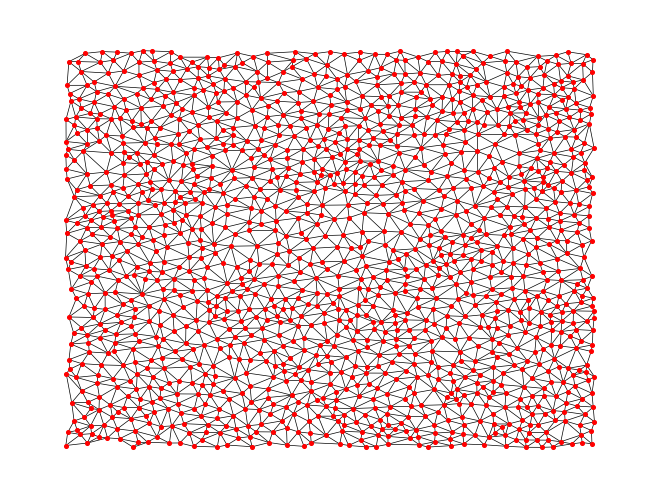

In [32]:
draw_pure_graph(vor_graph)

In [33]:
def add_to_nodes_ratio(graph: nx.Graph, ratios_in_order: np.ndarray, ratio_name: str) -> None:
    ratio_dict = {i: ratio for i, ratio in enumerate(ratios_in_order)}

    nx.set_node_attributes(graph, ratio_dict, ratio_name)

In [34]:
ratios_names = ["ERKKTR_ratio", "FoxO3A_ratio"]

for ratio_name in ratios_names:
    add_to_nodes_ratio(vor_graph, sorted_main_df.loc[0][ratio_name].to_numpy(), ratio_name)

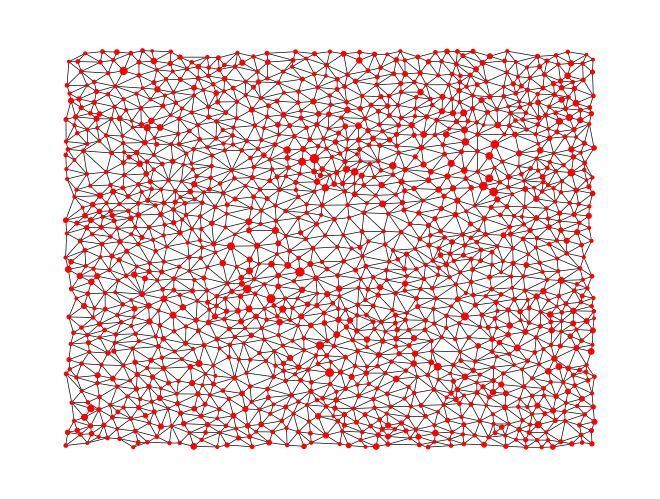

In [35]:
nx.draw(
    vor_graph, 
    node_size=[np.pi * (value+0.5) ** 2.5 for value in nx.get_node_attributes(vor_graph, "ERKKTR_ratio").values()], 
    width = 0.5, 
    with_labels=False, 
    pos=nx.get_node_attributes(vor_graph, "pos"), 
    node_color = 'red',
    
)